# Dictionaries

In [2]:
# --- Standard Imports
import os
from pathlib import Path
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import plotly.express as px
import geopandas as gpd

# Import Customers and Flights Clean Datasets

In [3]:
# directory with raw CSV files
data_dir = Path("../data/cleaned")

# list all CSV files
csv_files = list(data_dir.glob("*.csv"))
print(f"Found CSV files: {[f.name for f in csv_files]}")

Found CSV files: ['customers_cleaned.csv', 'flights_cleaned.csv']


In [4]:
# specify the files we want to load
customers_file = data_dir / "customers_cleaned.csv"
flights_file   = data_dir / "flights_cleaned.csv"

# load them with pandas
customers = pd.read_csv(customers_file)
flights   = pd.read_csv(flights_file)

print("Customers shape:", customers.shape)
print("Flights shape:", flights.shape)

Customers shape: (16574, 21)
Flights shape: (596664, 10)


## Number of customers by City

C:\Users\Duarte\AppData\Local\Temp\ipykernel_15304\2863074747.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_counts, x="City", y="Count", palette="viridis")


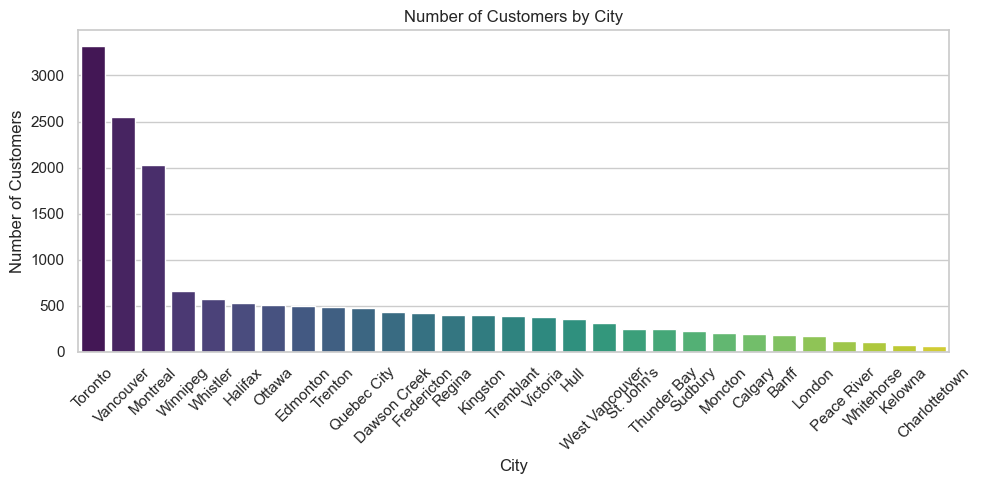

In [5]:
# Set style
sns.set(style="whitegrid")

# Calculate counts per city and sort descending
city_counts = customers["City"].value_counts().reset_index()
city_counts.columns = ["City", "Count"]

# Create bar chart ordered by number of customers
plt.figure(figsize=(10, 5))
sns.barplot(data=city_counts, x="City", y="Count", palette="viridis")

plt.title("Number of Customers by City")
plt.xlabel("City")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Import the Agregated dataset

In [6]:
# directory with agregated dataset
data_dir = Path("../data/aggregated/")

# list all CSV files
csv_files = list(data_dir.glob("*.csv"))
print(f"Found CSV files: {[f.name for f in csv_files]}")


Found CSV files: ['customers_aggregations.csv']


In [7]:
# specify the files we want to load
dataset = data_dir / "customers_aggregations.csv"

# load them with pandas
dataset = pd.read_csv(dataset)

print("dataset shape:", dataset.shape)

dataset shape: (16574, 31)


In [8]:
# display the first few rows of the dataframe
display(dataset.head(3))

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,...,EndDate,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,total_points_redeemed,total_cost_redeemed,points_redemption_ratio,companion_flight_ratio
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,...,2025-10-13,2432,216,53,507054.9,50699.39,13517.9,134.6,0.266628,0.245370
1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,...,2025-10-13,2410,286,30,426827.4,42672.54,22457.8,221.4,0.526282,0.104895
2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,...,2021-01-08,1274,143,37,238376.1,23832.41,5479.6,53.2,0.229922,0.258741


In [9]:
# Display basic info
print("\nFlightsDB basic info:")
print(dataset.info())


FlightsDB basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16574 entries, 0 to 16573
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Loyalty#                       16574 non-null  int64  
 1   First Name                     16574 non-null  object 
 2   Last Name                      16574 non-null  object 
 3   Customer Name                  16574 non-null  object 
 4   Country                        16574 non-null  object 
 5   Province or State              16574 non-null  object 
 6   City                           16574 non-null  object 
 7   Latitude                       16574 non-null  float64
 8   Longitude                      16574 non-null  float64
 9   Postal code                    16574 non-null  object 
 10  Gender                         16574 non-null  object 
 11  Education                      16574 non-null  object 
 12  Location Code          

In [10]:
dataset.columns

Index(['Loyalty#', 'First Name', 'Last Name', 'Customer Name', 'Country',
       'Province or State', 'City', 'Latitude', 'Longitude', 'Postal code',
       'Gender', 'Education', 'Location Code', 'Income', 'Marital Status',
       'LoyaltyStatus', 'EnrollmentDateOpening', 'CancellationDate',
       'Customer Lifetime Value', 'EnrollmentType', 'IsActive', 'EndDate',
       'CustomerTenureDays', 'total_flights', 'total_flights_with_companions',
       'total_distance', 'total_points_accumulated', 'total_points_redeemed',
       'total_cost_redeemed', 'points_redemption_ratio',
       'companion_flight_ratio'],
      dtype='object')

In [11]:
# Basic Descriptive Statistics
dataset.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loyalty#,16574.0,NaN,NaN,NaN,549435.680825,258874.788435,100018.0,326235.5,550020.0,771895.75,999986.0
First Name,16574,4926,Deon,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Last Name,16574,15116,Salberg,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,16574,16574,Ariane Peyton,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,16574,1,Canada,16574,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Province or State,16574,11,Ontario,5354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,16574,29,Toronto,3323,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,16574.0,NaN,NaN,NaN,47.174633,3.305623,42.984924,44.231171,46.087818,49.28273,60.721188
Longitude,16574.0,NaN,NaN,NaN,-91.840494,22.240412,-135.05684,-120.23766,-79.383186,-74.596184,-52.712578
Postal code,16574,55,V6E 3D9,906,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Income Analysis

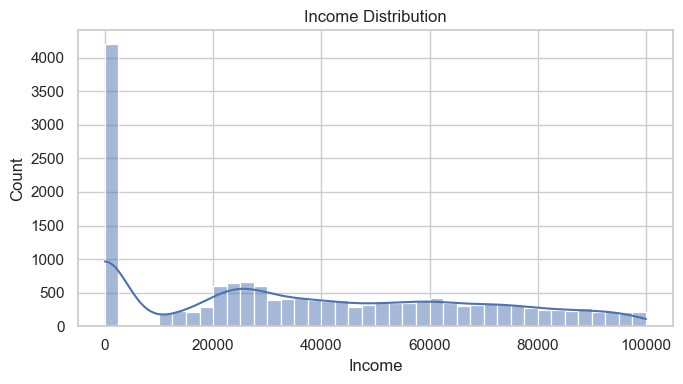

Income summary:
          Income
count  16574.00
mean   37739.99
std    30355.91
min        0.00
10%        0.00
25%        0.00
50%    34137.00
75%    62373.75
90%    81946.40
95%    90330.00
max    99981.00


In [12]:
# Income distribution

plt.figure(figsize=(7,4))
sns.histplot(dataset["Income"].dropna(), bins=40, kde=True)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

desc = dataset["Income"].describe(percentiles=[.1,.25,.5,.75,.9,.95]).to_frame("Income").round(2)
print("Income summary:\n", desc)

### We have a big number of customers with no income, Why is that?

In [13]:
zero_income = dataset[dataset["Income"] == 0]
"""customer with income = 0"""

'customer with income = 0'

In [14]:
print("=== Gender ===")
print(zero_income["Gender"].value_counts())
print("\n=== Marital Status ===")
print(zero_income["Marital Status"].value_counts())
print("\n=== Education ===")
print(zero_income["Education"].value_counts())

=== Gender ===
Gender
male      2137
female    2061
Name: count, dtype: int64

=== Marital Status ===
Marital Status
Single      2403
Married     1425
Divorced     370
Name: count, dtype: int64

=== Education ===
Education
College    4198
Name: count, dtype: int64


In [15]:
print("=== Location Code ===")
print(zero_income["Location Code"].value_counts())
print("\n=== EnrollmentType ===")
print(zero_income["EnrollmentType"].value_counts())
print("\n=== LoyaltyStatus ===")
print(zero_income["LoyaltyStatus"].value_counts())

=== Location Code ===
Location Code
Rural       1422
Urban       1406
Suburban    1370
Name: count, dtype: int64

=== EnrollmentType ===
EnrollmentType
Standard          3913
2021 Promotion     285
Name: count, dtype: int64

=== LoyaltyStatus ===
LoyaltyStatus
Star      2096
Nova      1319
Aurora     783
Name: count, dtype: int64


C:\Users\Duarte\AppData\Local\Temp\ipykernel_15304\1366238634.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=zero_income, x="Gender", palette="Set2", ax=axes[0, 0])
C:\Users\Duarte\AppData\Local\Temp\ipykernel_15304\1366238634.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=zero_income, x="Marital Status", palette="Set3", ax=axes[0, 1])
C:\Users\Duarte\AppData\Local\Temp\ipykernel_15304\1366238634.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=zero_income, x="Education", palette="Set1", ax=axes[0, 2])
C:\

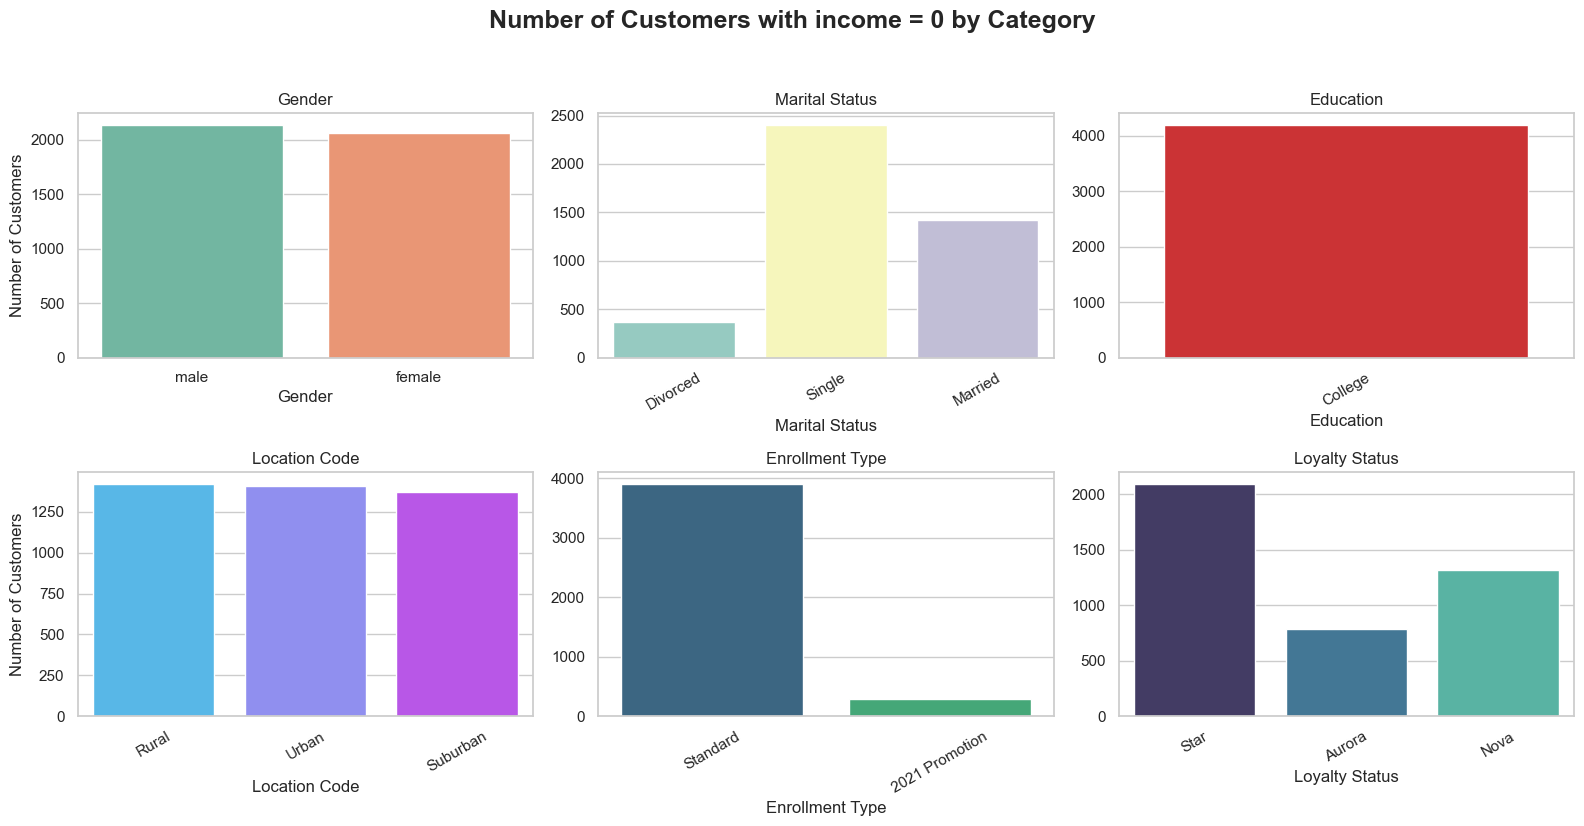

In [16]:
# Set style
sns.set(style="whitegrid")

# Create figure with 6 subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Number of customers by Gender
sns.countplot(data=zero_income, x="Gender", palette="Set2", ax=axes[0, 0])
axes[0, 0].set_title("Gender")
axes[0, 0].set_xlabel("Gender")
axes[0, 0].set_ylabel("Number of Customers")

# Number of customers by Marital Status
sns.countplot(data=zero_income, x="Marital Status", palette="Set3", ax=axes[0, 1])
axes[0, 1].set_title("Marital Status")
axes[0, 1].set_xlabel("Marital Status")
axes[0, 1].set_ylabel("")
axes[0, 1].tick_params(axis='x', rotation=30)

# Number of customers by Education
sns.countplot(data=zero_income, x="Education", palette="Set1", ax=axes[0, 2])
axes[0, 2].set_title("Education")
axes[0, 2].set_xlabel("Education")
axes[0, 2].set_ylabel("")
axes[0, 2].tick_params(axis='x', rotation=30)

# Number of customers by Location Code
sns.countplot(data=zero_income, x="Location Code", palette="cool", ax=axes[1, 0])
axes[1, 0].set_title("Location Code")
axes[1, 0].set_xlabel("Location Code")
axes[1, 0].set_ylabel("Number of Customers")
axes[1, 0].tick_params(axis='x', rotation=30)

# Number of customers by Enrollment Type
sns.countplot(data=zero_income, x="EnrollmentType", palette="viridis", ax=axes[1, 1])
axes[1, 1].set_title("Enrollment Type")
axes[1, 1].set_xlabel("Enrollment Type")
axes[1, 1].set_ylabel("")
axes[1, 1].tick_params(axis='x', rotation=30)

# Number of customers by Loyalty Status
sns.countplot(data=zero_income, x="LoyaltyStatus", palette="mako", ax=axes[1, 2])
axes[1, 2].set_title("Loyalty Status")
axes[1, 2].set_xlabel("Loyalty Status")
axes[1, 2].set_ylabel("")
axes[1, 2].tick_params(axis='x', rotation=30)

# Add general title
fig.suptitle("Number of Customers with income = 0 by Category", fontsize=18, fontweight='bold', y=1.03)

# Adjust layout
plt.tight_layout()
plt.show()

In [17]:
(dataset.loc[dataset["Education"] == "College", "Income"] == 0).all()

np.True_

For the analysis done above we can conclude that customer with income = 0:  
    - All have a education degree = College (the lowest one in our dataset). We can also see that all college customer have an income of 0  
    - The majority are Single  
    - Almost all have a Standard Enrollment Type

In [18]:
print("\n=== City ===")
print(zero_income["City"].value_counts())


=== City ===
City
Toronto           831
Vancouver         652
Montreal          538
Winnipeg          172
Whistler          160
Trenton           129
Ottawa            128
Edmonton          127
Halifax           116
Victoria          105
Regina            104
Kingston          103
Fredericton       100
Quebec City       100
Dawson Creek       98
Tremblant          89
Hull               88
West Vancouver     74
Sudbury            68
Thunder Bay        67
St. John's         65
Calgary            52
London             47
Moncton            46
Banff              44
Whitehorse         31
Peace River        23
Kelowna            22
Charlottetown      19
Name: count, dtype: int64


C:\Users\Duarte\AppData\Local\Temp\ipykernel_15304\99857658.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_counts, x="City", y="Count", palette="viridis")


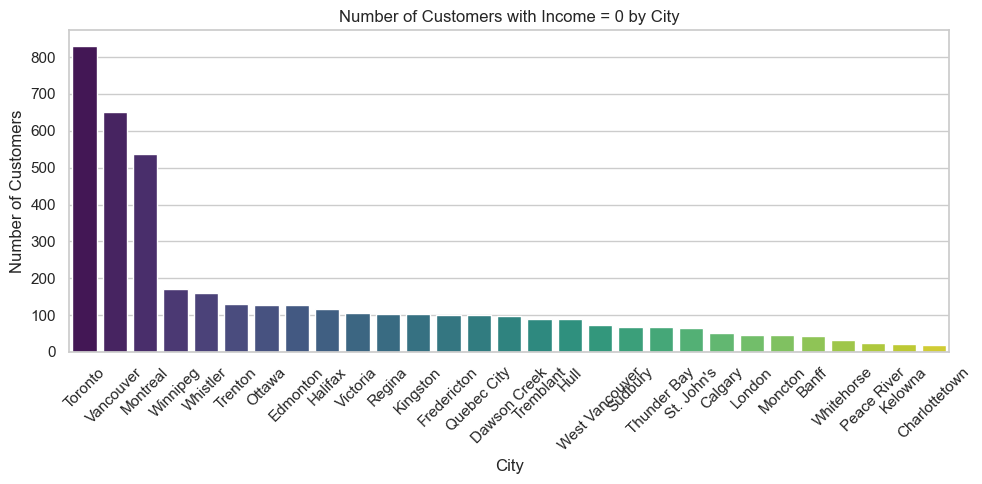

In [19]:
# Set style
sns.set(style="whitegrid")

# Calculate counts per city and sort descending
city_counts = zero_income["City"].value_counts().reset_index()
city_counts.columns = ["City", "Count"]

# Create figure
plt.figure(figsize=(10, 5))

# Bar chart: Number of customers by City
sns.barplot(data=city_counts, x="City", y="Count", palette="viridis")

plt.title("Number of Customers with Income = 0 by City")
plt.xlabel("City")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The distibution by City is completly align with the one where we consider all types of income. Nothing to add here.

In [20]:
print("\n=== IsActive ===")
print(zero_income["IsActive"].value_counts())


=== IsActive ===
IsActive
1    3623
0     575
Name: count, dtype: int64


The Majority of customer with income = 0 are still active

### Regarding customers with income = 0, the data seems valid

For the remaining Income Analysis we will only consider income > 0

## Levels of Income by Education

In [21]:
non_zero_income = dataset[dataset["Income"] != 0]
"""customer with income different from 0"""

'customer with income different from 0'

C:\Users\Duarte\AppData\Local\Temp\ipykernel_15304\2730096441.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=non_zero_income, x="Education", y="Income", palette="Set2")


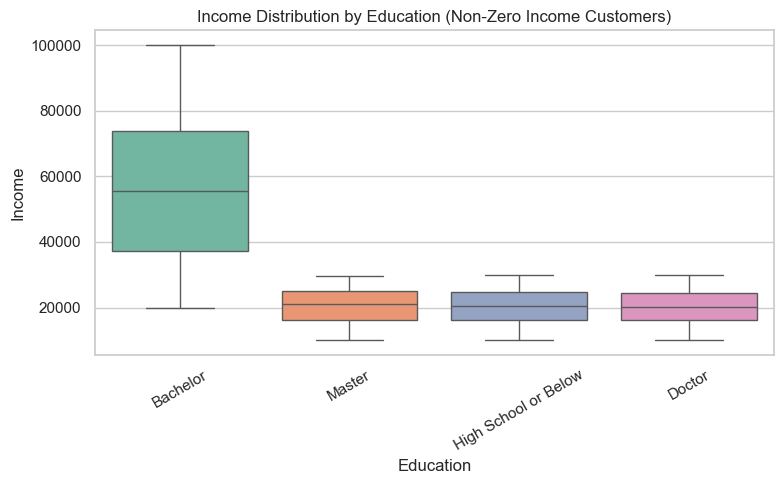

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=non_zero_income, x="Education", y="Income", palette="Set2")

plt.title("Income Distribution by Education (Non-Zero Income Customers)")
plt.xlabel("Education")
plt.ylabel("Income")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Its weird that the Income of Masters and Doctor is not bigger than the bachelor one. We can have here some outliers on the bachelor poll. To be checked

## Levels of Income by Marital Status

C:\Users\Duarte\AppData\Local\Temp\ipykernel_15304\673810015.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=non_zero_income, x="Marital Status", y="Income", palette="Set2")


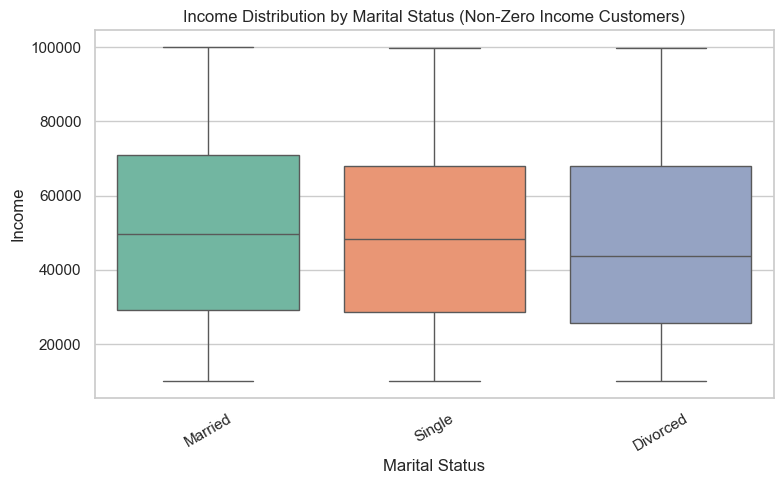

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=non_zero_income, x="Marital Status", y="Income", palette="Set2")

plt.title("Income Distribution by Marital Status (Non-Zero Income Customers)")
plt.xlabel("Marital Status")
plt.ylabel("Income")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Nothing to add here. Income well distributed between martital status.

## Levels of Income by Gender

C:\Users\Duarte\AppData\Local\Temp\ipykernel_15304\1405924094.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=non_zero_income, x="Gender", y="Income", palette="Set2")


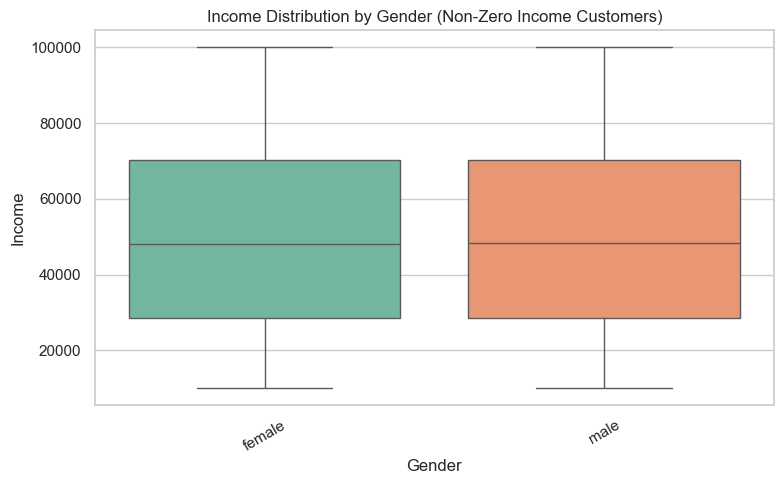

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=non_zero_income, x="Gender", y="Income", palette="Set2")

plt.title("Income Distribution by Gender (Non-Zero Income Customers)")
plt.xlabel("Gender")
plt.ylabel("Income")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Nothing to add here. Income well distributed between gender.

## Levels of Income by Loyalty Status

C:\Users\Duarte\AppData\Local\Temp\ipykernel_15304\742682327.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=non_zero_income, x="LoyaltyStatus", y="Income", palette="Set2")


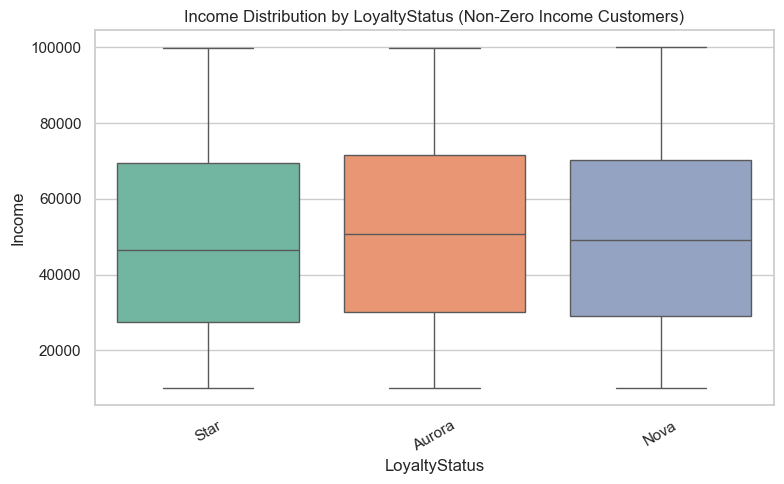

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=non_zero_income, x="LoyaltyStatus", y="Income", palette="Set2")

plt.title("Income Distribution by LoyaltyStatus (Non-Zero Income Customers)")
plt.xlabel("LoyaltyStatus")
plt.ylabel("Income")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Nothing to add here. Income well distributed between Loyalty Status.

## Levels of Income by CustomerLifetimeValue

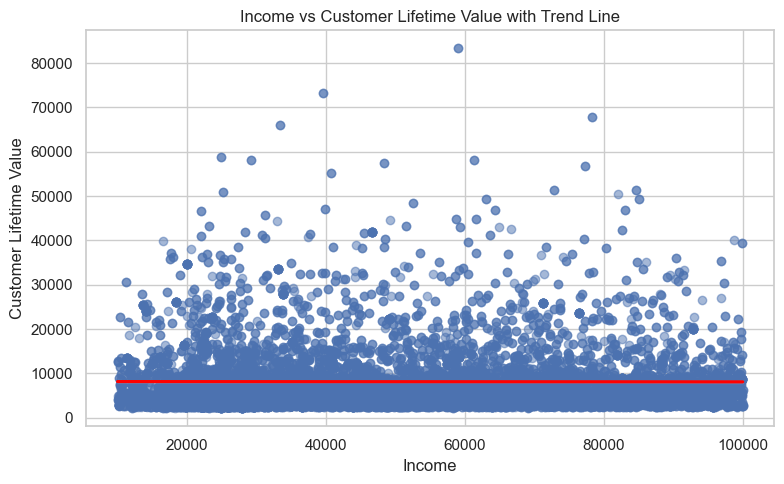

In [48]:
plt.figure(figsize=(8, 5))
sns.regplot(data=non_zero_income, x="Income", y="Customer Lifetime Value", scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title("Income vs Customer Lifetime Value with Trend Line")
plt.xlabel("Income")
plt.ylabel("Customer Lifetime Value")
plt.tight_layout()
plt.show()

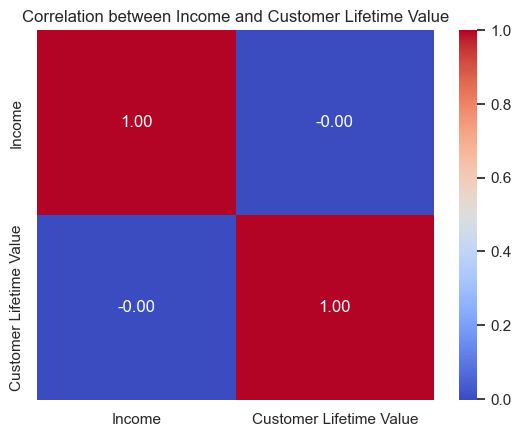

In [49]:
corr = non_zero_income[["Income", "Customer Lifetime Value"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Income and Customer Lifetime Value")
plt.show()

### There is no correlation between income and CustomerLifeTimeValue

# Gender Analysis

## Gender by number of customers

C:\Users\Duarte\AppData\Local\Temp\ipykernel_15304\831069441.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataset, x="Gender", palette="pastel", order=dataset["Gender"].value_counts().index)


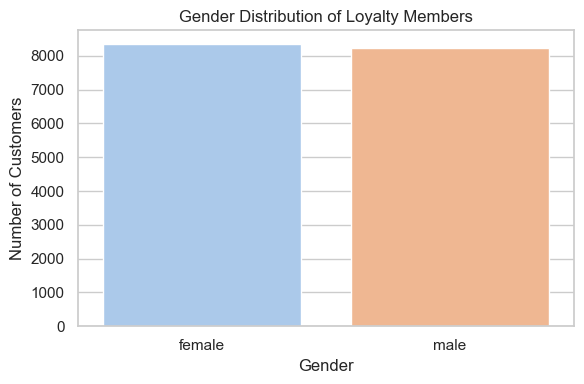


Gender distribution (%):
Gender
female    50.3
male      49.7
Name: proportion, dtype: float64


In [52]:
plt.figure(figsize=(6,4))
sns.countplot(data=dataset, x="Gender", palette="pastel", order=dataset["Gender"].value_counts().index)
plt.title("Gender Distribution of Loyalty Members")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

print("\nGender distribution (%):")
print((dataset["Gender"].value_counts(normalize=True) * 100).round(1))

## Gender by Education

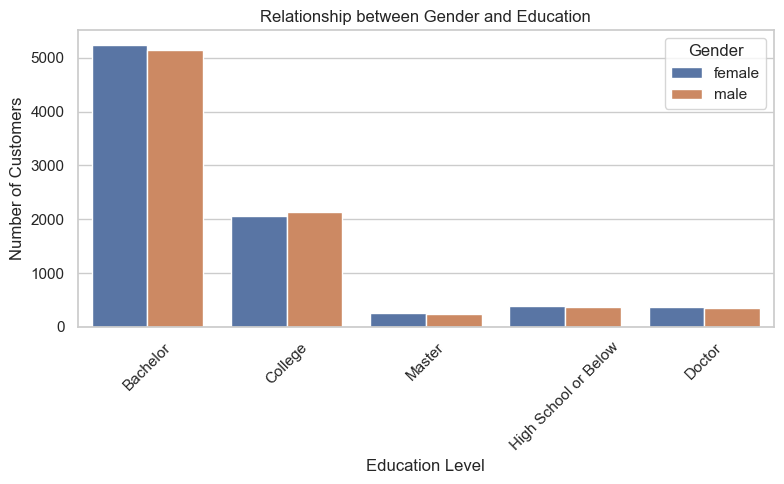

In [53]:
# Assuming your DataFrame is named 'dataset'
plt.figure(figsize=(8, 5))

# Countplot to show the distribution
sns.countplot(data=dataset, x='Education', hue='Gender')

plt.title('Relationship between Gender and Education')
plt.xlabel('Education Level')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

## Gender by Loyalty Status

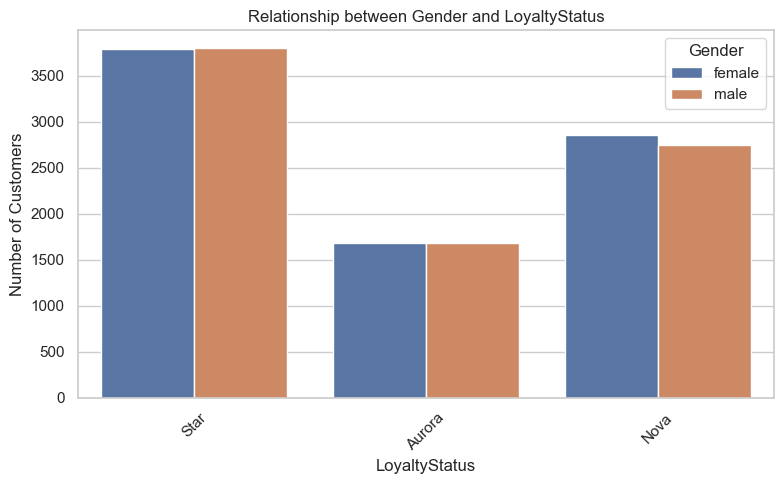

In [54]:
# Assuming your DataFrame is named 'dataset'
plt.figure(figsize=(8, 5))

# Countplot to show the distribution
sns.countplot(data=dataset, x='LoyaltyStatus', hue='Gender')

plt.title('Relationship between Gender and LoyaltyStatus')
plt.xlabel('LoyaltyStatus')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

## Gender by CustomerLifeTimeValue

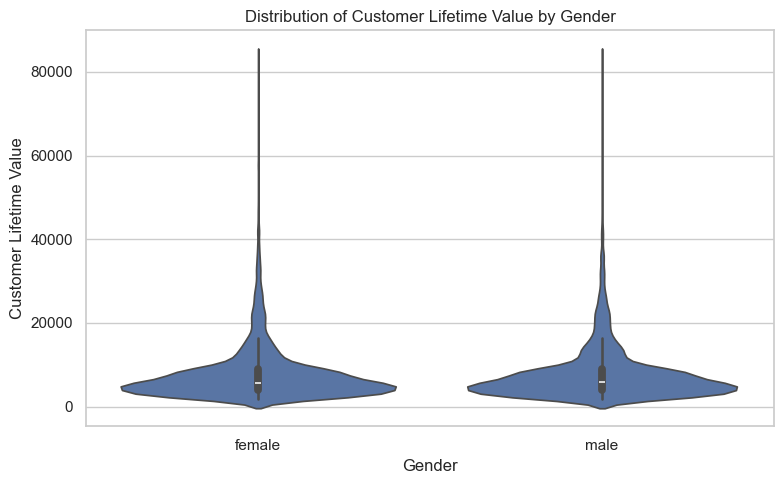

In [60]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=dataset, x='Gender', y='Customer Lifetime Value', inner='box')
plt.title('Distribution of Customer Lifetime Value by Gender')
plt.xlabel('Gender')
plt.ylabel('Customer Lifetime Value')
plt.tight_layout()
plt.show()

C:\Users\Duarte\AppData\Local\Temp\ipykernel_15304\1555673567.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataset, x="Education", order=order, palette="muted")


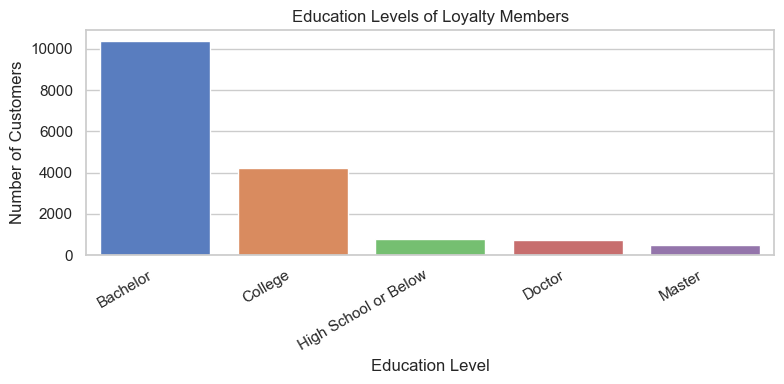


Education distribution (%):
Education
Bachelor                62.6
College                 25.3
High School or Below     4.7
Doctor                   4.4
Master                   3.0
Name: proportion, dtype: float64


In [28]:
# Education distibution

plt.figure(figsize=(8,4))
order = dataset["Education"].value_counts().index  # sort by most frequent
sns.countplot(data=dataset, x="Education", order=order, palette="muted")
plt.title("Education Levels of Loyalty Members")
plt.xlabel("Education Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("\nEducation distribution (%):")
print((dataset["Education"].value_counts(normalize=True) * 100).round(1))

C:\Users\Duarte\AppData\Local\Temp\ipykernel_15304\985453244.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataset, x="Marital Status", palette="pastel", order=dataset["Marital Status"].value_counts().index)


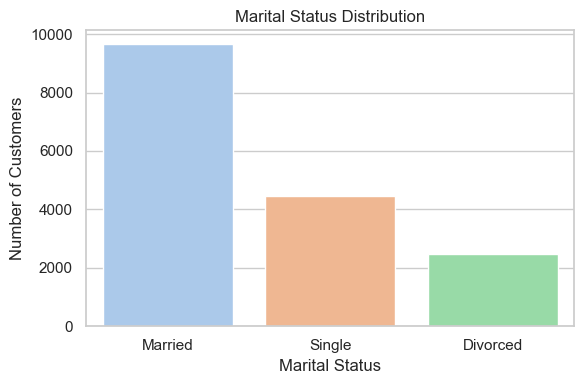


Marital Status (%):
Marital Status
Married     58.2
Single      26.8
Divorced    15.0
Name: proportion, dtype: float64


In [29]:
# Marital Status

plt.figure(figsize=(6,4))
sns.countplot(data=dataset, x="Marital Status", palette="pastel", order=dataset["Marital Status"].value_counts().index)
plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

print("\nMarital Status (%):")
print((dataset["Marital Status"].value_counts(normalize=True) * 100).round(1))

In [30]:
# Province counts
prov_counts = (
    dataset["Province or State"]
    .value_counts(dropna=False)
    .rename_axis("Province")
    .reset_index(name="CustomerCount")
)
print(prov_counts.head(10))

# City counts (ranked)
city_counts = (
    dataset.groupby(["Province or State", "City"])
    .size()
    .reset_index(name="CustomerCount")
    .sort_values("CustomerCount", ascending=False)
)
print(city_counts.head(15))

           Province  CustomerCount
0           Ontario           5354
1  British Columbia           4333
2            Quebec           3245
3           Alberta            987
4          Manitoba            666
5     New Brunswick            629
6       Nova Scotia            529
7      Saskatchewan            404
8      Newfoundland            253
9             Yukon            108
   Province or State          City  CustomerCount
20           Ontario       Toronto           3323
6   British Columbia     Vancouver           2551
24            Quebec      Montreal           2028
10          Manitoba      Winnipeg            666
9   British Columbia      Whistler            579
14       Nova Scotia       Halifax            529
17           Ontario        Ottawa            505
2            Alberta      Edmonton            496
21           Ontario       Trenton            482
25            Quebec   Quebec City            472
4   British Columbia  Dawson Creek            434
11     New Brun

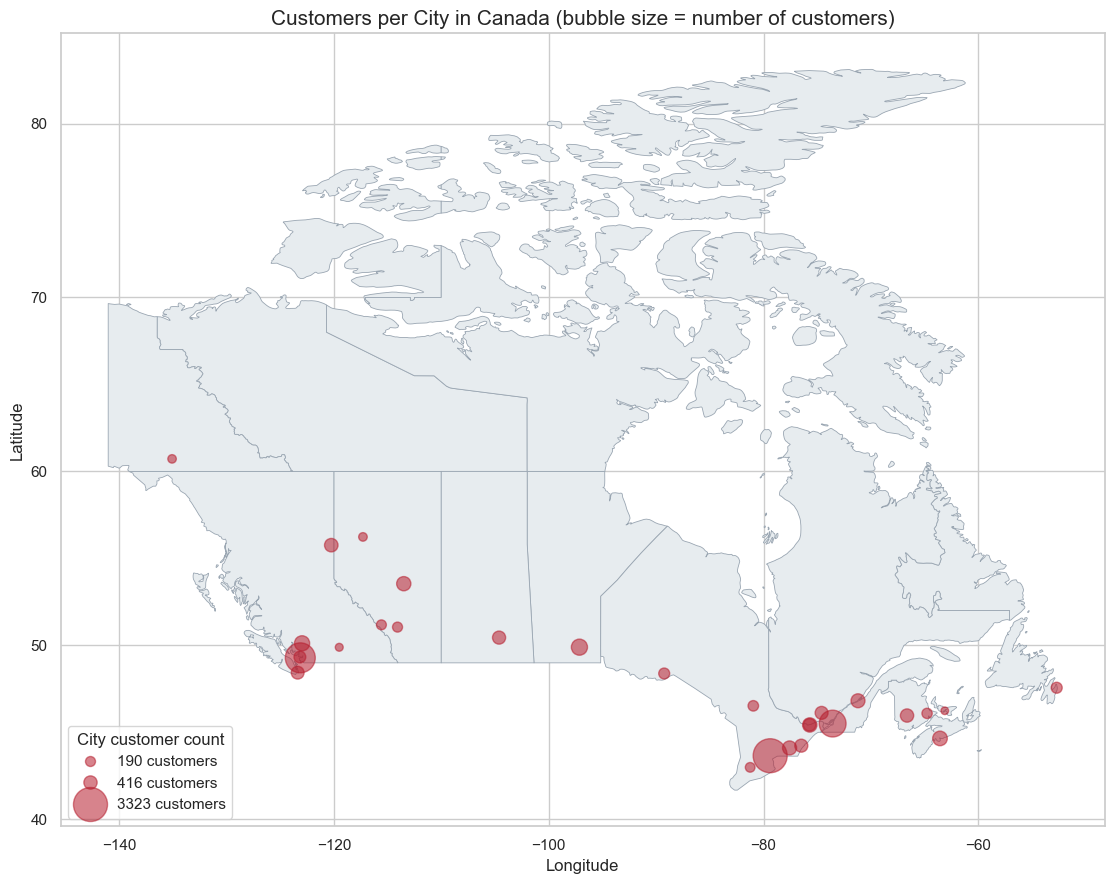

In [31]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 1) Prepare data
df = dataset.copy()
df["Latitude"]  = pd.to_numeric(df["Latitude"],  errors="coerce")
df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")
df = df.dropna(subset=["Latitude", "Longitude"]).reset_index(drop=True)

# Aggregate customers per city
city_agg = (
    df.groupby(["Province or State", "City"])
      .agg(CustomerCount=("City", "size"),
           Latitude=("Latitude", "mean"),
           Longitude=("Longitude", "mean"))
      .reset_index()
)

# 2) Canada provinces layer
admin1_url = "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces.zip"
admin1 = gpd.read_file(admin1_url).to_crs("EPSG:4326")
canada_admin1 = admin1.loc[admin1["admin"] == "Canada", ["name", "geometry"]].copy()

# 3) GeoDataFrame for city bubbles
cities_gdf = gpd.GeoDataFrame(
    city_agg,
    geometry=gpd.points_from_xy(city_agg["Longitude"], city_agg["Latitude"]),
    crs="EPSG:4326"
)

# 4) Size scaling (scatter 's' is area in points^2)
counts = cities_gdf["CustomerCount"].astype(float).values
size_min, size_max = 30, 600  # adjust if needed
if counts.size > 0:
    cmin, cmax = counts.min(), counts.max()
    if cmin == cmax:
        sizes = np.full_like(counts, (size_min + size_max) / 2.0)
    else:
        sizes = np.interp(counts, (cmin, cmax), (size_min, size_max))
else:
    sizes = np.array([])

# 5) Plot
fig, ax = plt.subplots(figsize=(12, 9))
canada_admin1.plot(ax=ax, color="#E7ECEF", edgecolor="#9AA6B2", linewidth=0.6)

cities_gdf.plot(
    ax=ax,
    markersize=sizes,            # bubble sizes (area)
    color="#B61E2E",
    alpha=0.55
)

ax.set_title("Customers per City in Canada (bubble size = number of customers)", fontsize=15)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

# --- Custom bubble legend (robust across Matplotlib versions) ---
if counts.size > 0:
    # Choose representative counts (min, median, max or 3 quantiles)
    reps = np.unique(np.ceil(np.quantile(counts, [0.2, 0.6, 1.0])).astype(int))
    # Map those counts to scatter areas and then to Line2D marker sizes (radius ~ sqrt(area))
    rep_sizes = []
    for r in reps:
        if cmin == cmax:
            s = (size_min + size_max) / 2.0
        else:
            s = np.interp(r, (cmin, cmax), (size_min, size_max))
        rep_sizes.append(s)

    handles = [
        Line2D([0], [0],
               marker='o', linestyle='',
               markersize=np.sqrt(s),   # convert area to marker size
               markerfacecolor="#B61E2E", markeredgecolor="#B61E2E", alpha=0.55)
        for s in rep_sizes
    ]
    labels = [f"{int(r)} customers" for r in reps]
    ax.legend(handles, labels, title="City customer count", frameon=True, loc="lower left")

plt.tight_layout(); plt.show()



In [32]:
# Frequencies and % share
for col in ["LoyaltyStatus", "IsActive", "EnrollmentType"]:
    print(f"\n=== {col} (counts) ===")
    print(dataset[col].value_counts(dropna=False))
    print(f"\n=== {col} (%) ===")
    print((dataset[col].value_counts(normalize=True, dropna=False) * 100).round(1))


=== LoyaltyStatus (counts) ===
LoyaltyStatus
Star      7598
Nova      5611
Aurora    3365
Name: count, dtype: int64

=== LoyaltyStatus (%) ===
LoyaltyStatus
Star      45.8
Nova      33.9
Aurora    20.3
Name: proportion, dtype: float64

=== IsActive (counts) ===
IsActive
1    14327
0     2247
Name: count, dtype: int64

=== IsActive (%) ===
IsActive
1    86.4
0    13.6
Name: proportion, dtype: float64

=== EnrollmentType (counts) ===
EnrollmentType
Standard          15436
2021 Promotion     1138
Name: count, dtype: int64

=== EnrollmentType (%) ===
EnrollmentType
Standard          93.1
2021 Promotion     6.9
Name: proportion, dtype: float64


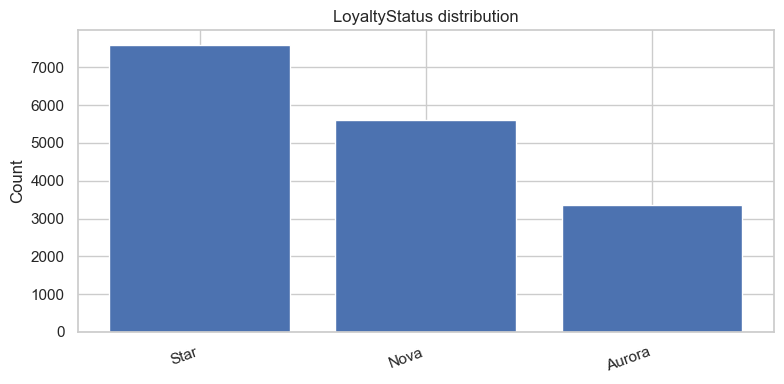

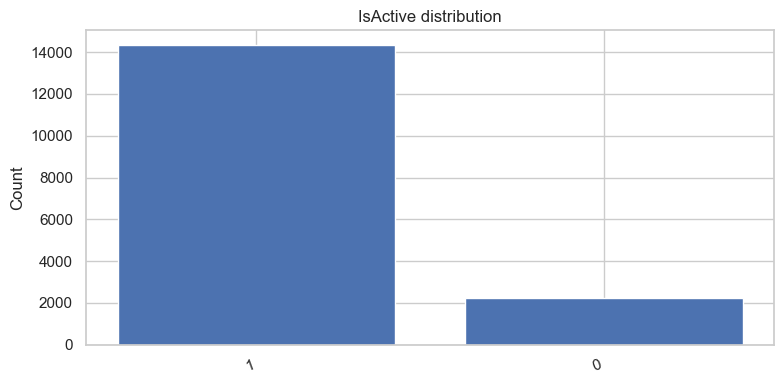

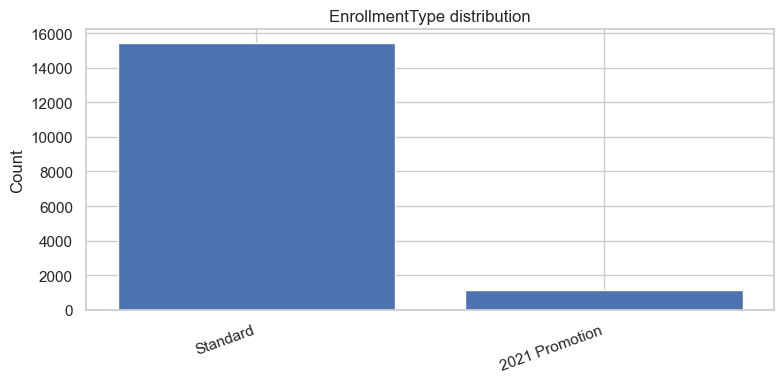

In [33]:
# Simple bar charts (one column at a time)

def bar_counts(df, col, top_n=None):
    counts = df[col].value_counts().head(top_n) if top_n else df[col].value_counts()
    plt.figure(figsize=(8,4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"{col} distribution")
    plt.ylabel("Count"); plt.xticks(rotation=20, ha="right")
    plt.tight_layout(); plt.show()

bar_counts(dataset, "LoyaltyStatus")
bar_counts(dataset, "IsActive")
bar_counts(dataset, "EnrollmentType")

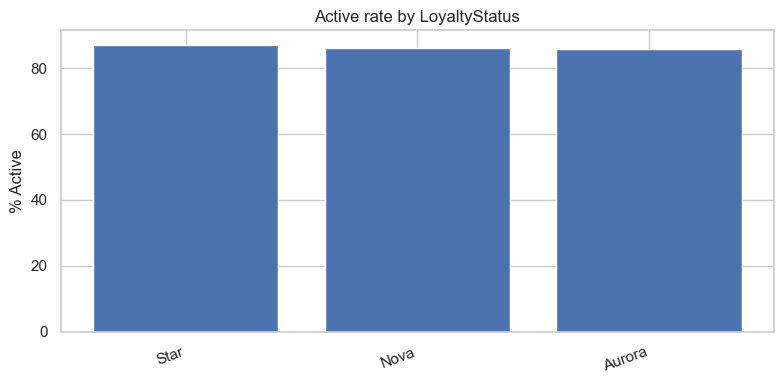

LoyaltyStatus
Star      87.1%
Nova      86.1%
Aurora    85.6%
Name: ActiveRate, dtype: object


In [34]:
# % Active by LoyaltyStatus (activation rate)

# If IsActive is booleans or {0,1}; coerce if needed
active_map = {True:1, False:0, "True":1, "False":0, "Y":1, "N":0, 1:1, 0:0}
tmp = dataset.copy()
tmp["IsActive_num"] = tmp["IsActive"].map(active_map)

active_rate = (
    tmp.groupby("LoyaltyStatus")["IsActive_num"]
       .mean()
       .sort_values(ascending=False)
       .rename("ActiveRate")
)

plt.figure(figsize=(8,4))
plt.bar(active_rate.index.astype(str), (active_rate.values*100))
plt.title("Active rate by LoyaltyStatus")
plt.ylabel("% Active"); plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

print(active_rate.mul(100).round(1).astype(str) + "%")

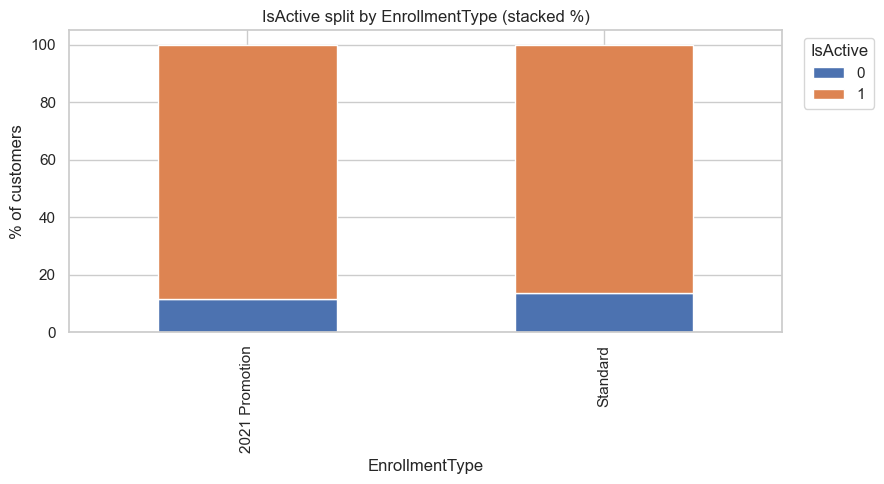


% breakdown by EnrollmentType:
IsActive           0     1
EnrollmentType            
2021 Promotion  11.7  88.3
Standard        13.7  86.3


In [35]:
# Stacked % bar: EnrollmentType × IsActive

ct = pd.crosstab(dataset["EnrollmentType"], dataset["IsActive"])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# Plot stacked %
ax = ct_pct.plot(kind="bar", stacked=True, figsize=(9,5))
ax.set_title("IsActive split by EnrollmentType (stacked %)")
ax.set_ylabel("% of customers"); ax.set_xlabel("EnrollmentType")
ax.legend(title="IsActive", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

print("\n% breakdown by EnrollmentType:")
print(ct_pct.round(1))

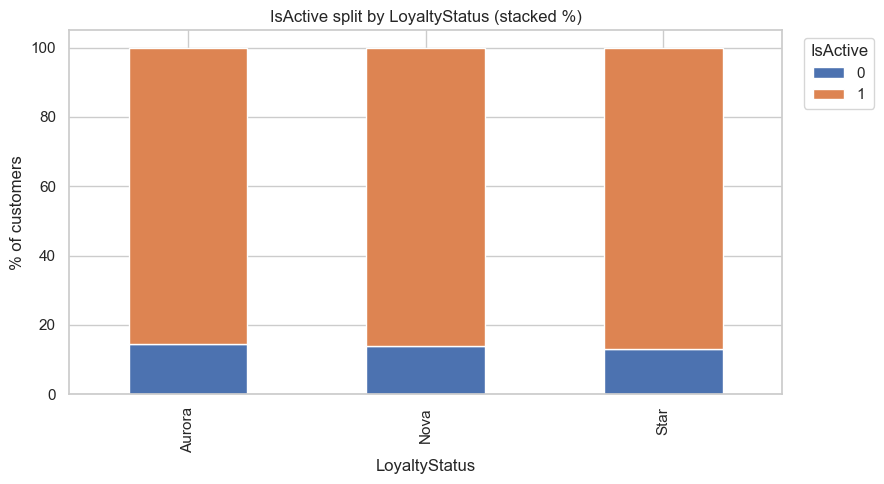


% breakdown by LoyaltyStatus:
IsActive          0     1
LoyaltyStatus            
Aurora         14.4  85.6
Nova           13.9  86.1
Star           12.9  87.1


In [36]:
# Stacked % bar: LoyaltyStatus × IsActive

ct2 = pd.crosstab(dataset["LoyaltyStatus"], dataset["IsActive"])
ct2_pct = ct2.div(ct2.sum(axis=1), axis=0) * 100

ax = ct2_pct.plot(kind="bar", stacked=True, figsize=(9,5))
ax.set_title("IsActive split by LoyaltyStatus (stacked %)")
ax.set_ylabel("% of customers"); ax.set_xlabel("LoyaltyStatus")
ax.legend(title="IsActive", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

print("\n% breakdown by LoyaltyStatus:")
print(ct2_pct.round(1))

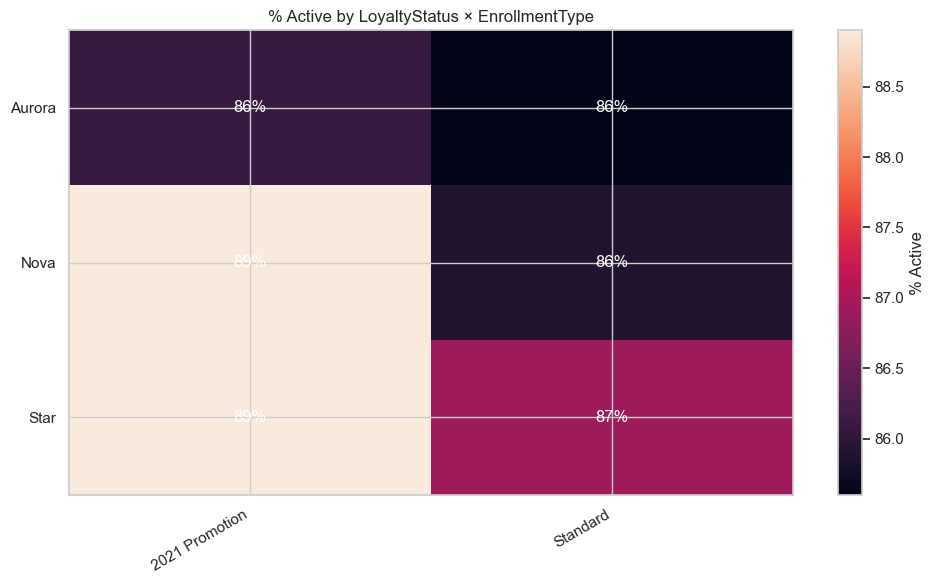


% Active (table):
EnrollmentType  2021 Promotion  Standard
LoyaltyStatus                           
Aurora                    86.1      85.6
Nova                      88.9      85.9
Star                      88.9      86.9


In [37]:
# Heatmap (matplotlib) of % Active for (LoyaltyStatus × EnrollmentType)

# Build % active pivot
active_map = {True:1, False:0, "True":1, "False":0, "Y":1, "N":0, 1:1, 0:0}
df = dataset.copy()
df["IsActive_num"] = df["IsActive"].map(active_map)

pivot = (
    df.pivot_table(
        index="LoyaltyStatus",
        columns="EnrollmentType",
        values="IsActive_num",
        aggfunc="mean"
    ) * 100
).round(1)

fig, ax = plt.subplots(figsize=(10,6))
im = ax.imshow(pivot.values, aspect="auto")

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("% Active", rotation=90)

# Ticks and labels
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
ax.set_yticklabels(pivot.index)
ax.set_title("% Active by LoyaltyStatus × EnrollmentType")

# Annotate cells
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if pd.notnull(val):
            ax.text(j, i, f"{val:.0f}%", ha="center", va="center", color="white" if val>=50 else "black")

plt.tight_layout(); plt.show()

print("\n% Active (table):")
print(pivot)

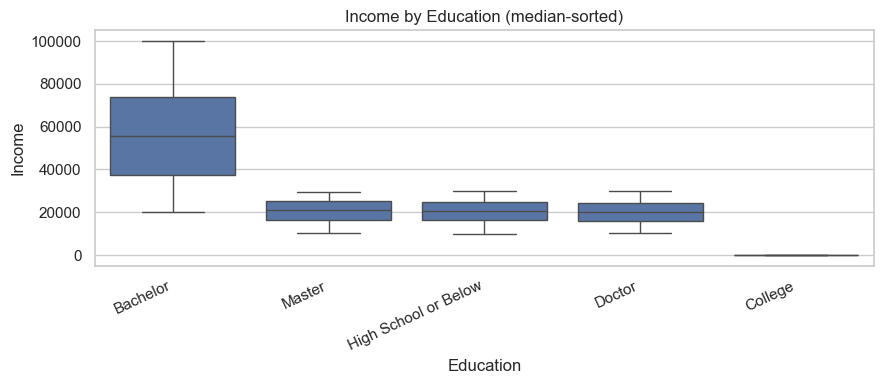

In [38]:
# Income by education

if set(["Income","Education"]).issubset(dataset.columns):
    # order education by median income (more interpretable)
    med = dataset.groupby("Education")["Income"].median().sort_values(ascending=False)
    plt.figure(figsize=(9,4))
    sns.boxplot(data=dataset, x="Education", y="Income", order=med.index, showfliers=False)
    plt.title("Income by Education (median-sorted)")
    plt.xlabel("Education")
    plt.ylabel("Income")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

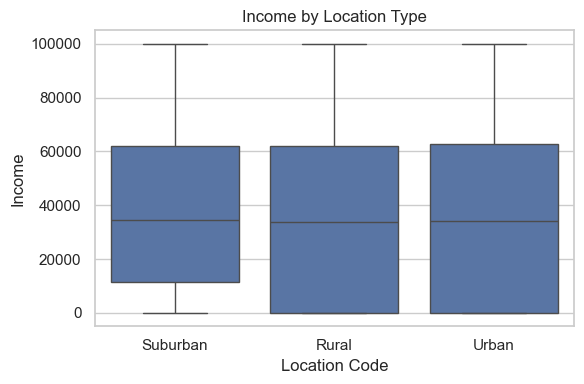

In [39]:
# Income by location code
if set(["Income","Location Code"]).issubset(dataset.columns):
    order = dataset["Location Code"].value_counts().index
    plt.figure(figsize=(6,4))
    sns.boxplot(data=dataset, x="Location Code", y="Income", order=order, showfliers=False)
    plt.title("Income by Location Type")
    plt.xlabel("Location Code")
    plt.ylabel("Income")
    plt.tight_layout()
    plt.show()

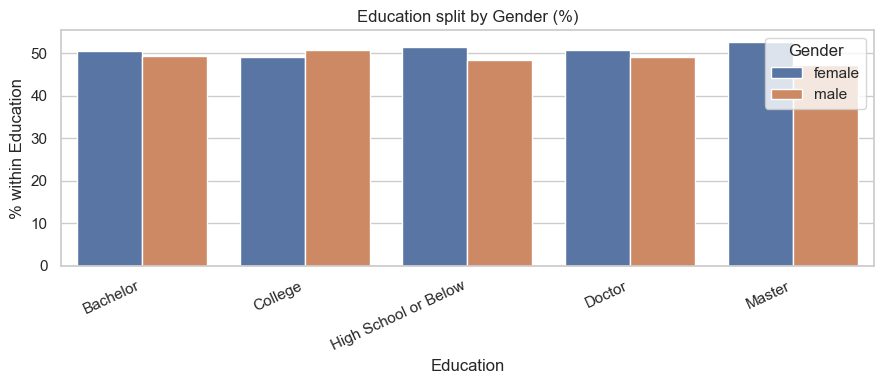

In [40]:
# Education split by gender

if set(["Education","Gender"]).issubset(dataset.columns):
    edu_gender = (
        dataset.groupby(["Education","Gender"])
        .size()
        .rename("count")
        .reset_index()  # this now keeps both columns safely
    )
    # compute % within each Education group
    edu_gender["pct"] = edu_gender.groupby("Education")["count"].transform(lambda x: x / x.sum() * 100)
    
    order_edu = dataset["Education"].value_counts().index
    plt.figure(figsize=(9,4))
    sns.barplot(data=edu_gender, x="Education", y="pct", hue="Gender", order=order_edu)
    plt.title("Education split by Gender (%)")
    plt.xlabel("Education")
    plt.ylabel("% within Education")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()


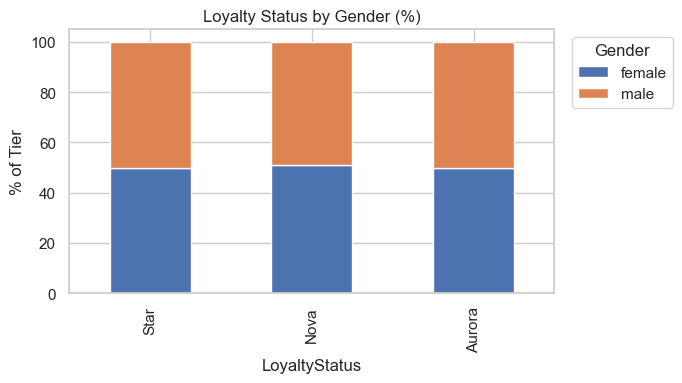

In [41]:
# loyalty status by gender

if set(["LoyaltyStatus","Gender"]).issubset(dataset.columns):
    ctab = pd.crosstab(dataset["LoyaltyStatus"], dataset["Gender"], normalize="index") * 100
    ctab = ctab.loc[dataset["LoyaltyStatus"].value_counts().index]  # order tiers by size
    ax = ctab.plot(kind="bar", stacked=True, figsize=(7,4))
    plt.title("Loyalty Status by Gender (%)")
    plt.ylabel("% of Tier")
    plt.xlabel("LoyaltyStatus")
    plt.legend(title="Gender", bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("LoyaltyStatus and/or Gender columns not found.")

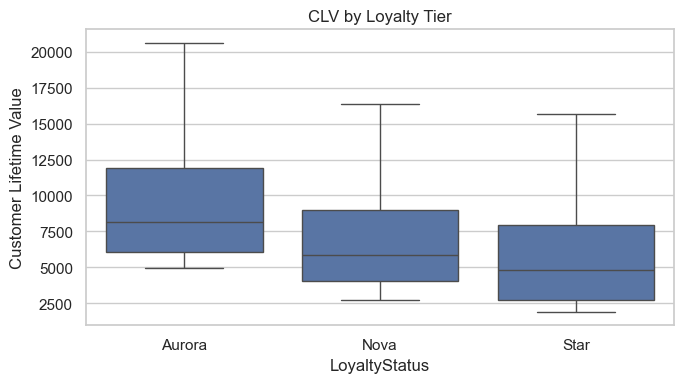

In [42]:
# CLV by LoyaltyStatus

if set(["Customer Lifetime Value","LoyaltyStatus"]).issubset(dataset.columns):
    order = (dataset.groupby("LoyaltyStatus")["Customer Lifetime Value"]
             .median().sort_values(ascending=False).index)
    plt.figure(figsize=(7,4))
    sns.boxplot(data=dataset, x="LoyaltyStatus", y="Customer Lifetime Value",
                order=order, showfliers=False)
    plt.title("CLV by Loyalty Tier")
    plt.xlabel("LoyaltyStatus")
    plt.ylabel("Customer Lifetime Value")
    plt.tight_layout()
    plt.show()
else:
    print("Customer Lifetime Value and/or LoyaltyStatus columns not found.")

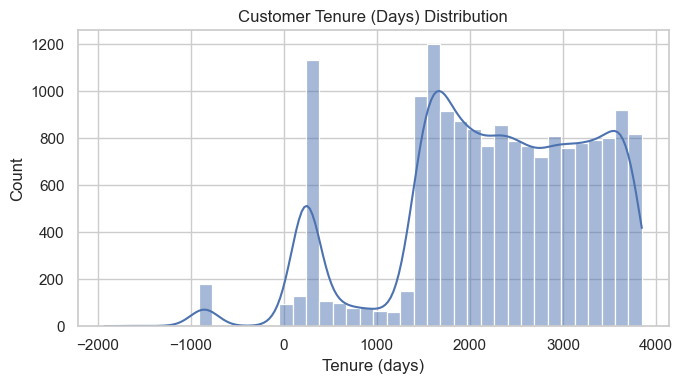

In [43]:
# Customer tenure distibution

if "CustomerTenureDays" in dataset.columns:
    plt.figure(figsize=(7,4))
    sns.histplot(dataset["CustomerTenureDays"].dropna(), bins=40, kde=True)
    plt.title("Customer Tenure (Days) Distribution")
    plt.xlabel("Tenure (days)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("CustomerTenureDays column not found.")

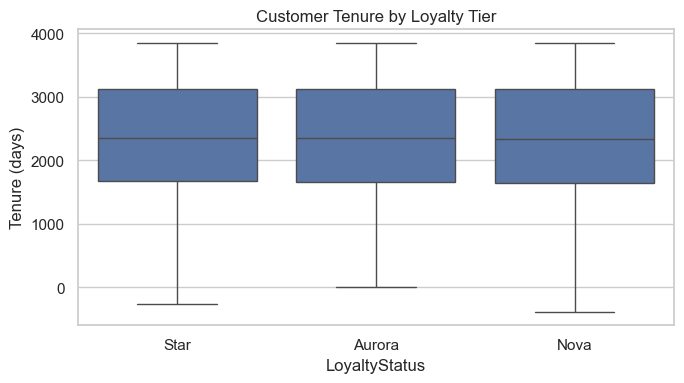

In [44]:
# Tenure by LoyaltyStatus

if set(["CustomerTenureDays","LoyaltyStatus"]).issubset(dataset.columns):
    order = (dataset.groupby("LoyaltyStatus")["CustomerTenureDays"]
             .median().sort_values(ascending=False).index)
    plt.figure(figsize=(7,4))
    sns.boxplot(data=dataset, x="LoyaltyStatus", y="CustomerTenureDays",
                order=order, showfliers=False)
    plt.title("Customer Tenure by Loyalty Tier")
    plt.xlabel("LoyaltyStatus")
    plt.ylabel("Tenure (days)")
    plt.tight_layout()
    plt.show()
else:
    print("CustomerTenureDays and/or LoyaltyStatus columns not found.")

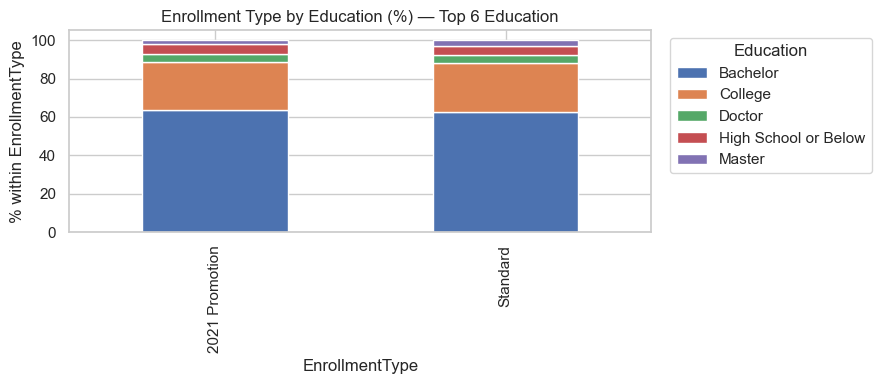

In [45]:
# EnrollmentType by Education

if set(["EnrollmentType","Education"]).issubset(dataset.columns):
    # limit to top education categories to avoid clutter
    top_edu = dataset["Education"].value_counts().nlargest(6).index
    sub = dataset[dataset["Education"].isin(top_edu)].copy()
    ctab = pd.crosstab(sub["EnrollmentType"], sub["Education"], normalize="index") * 100
    ax = ctab.plot(kind="bar", stacked=True, figsize=(9,4))
    plt.title("Enrollment Type by Education (%) — Top 6 Education")
    plt.ylabel("% within EnrollmentType")
    plt.xlabel("EnrollmentType")
    plt.legend(title="Education", bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("EnrollmentType and/or Education columns not found.")

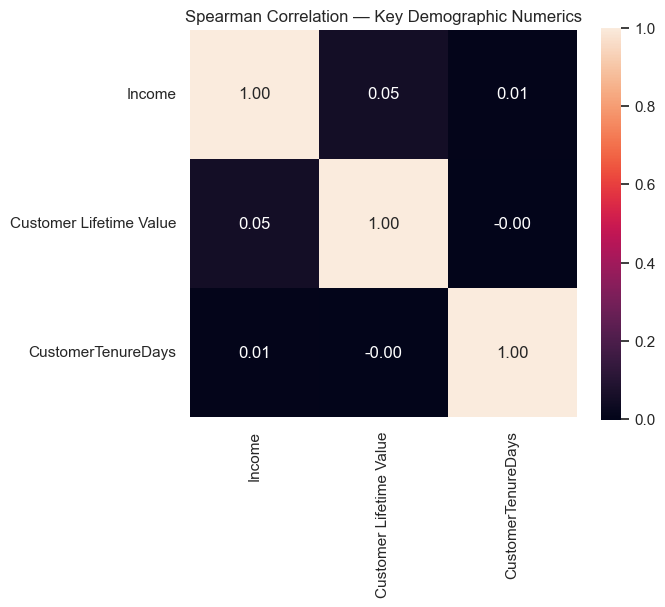

In [46]:
# Correlation heatmap

num_cols = [c for c in ["Income","Customer Lifetime Value","CustomerTenureDays"] if c in dataset.columns]
if len(num_cols) >= 2:
    plt.figure(figsize=(4+len(num_cols), 3+len(num_cols)))
    corr = dataset[num_cols].corr(method="spearman")
    sns.heatmap(corr, annot=True, fmt=".2f", square=True, cbar=True)
    plt.title("Spearman Correlation — Key Demographic Numerics")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric demographic columns for correlation.")